This notebook is designed to test and perfect our analytic methods for a single trial of a single sample at a single temperature.

We will then generalize this to perform analysis on many trials at once

This will be then be turned into a helper .py script

In [2]:
# Import necessary librarys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [164]:
# Import .txt file

# Available samples: (PB2, SN, IN, SNPB, PTFE, IN2BI, IN4BI, CU, PB0, PB1)
# Replace blank in "sc_data/__/__..txt" with sample name
df = pd.read_csv("sc_data/PB2/PB2_3.0.txt", sep=r"\s+")

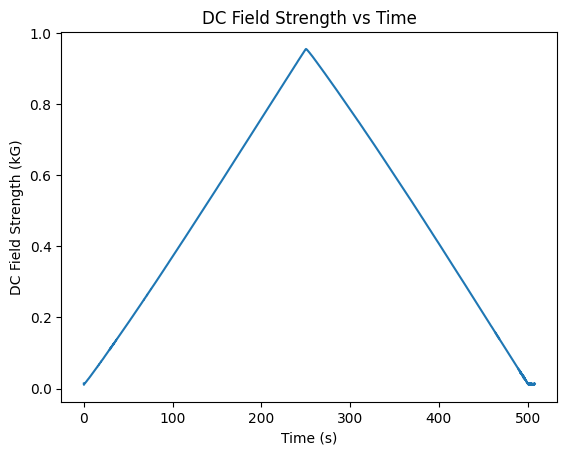

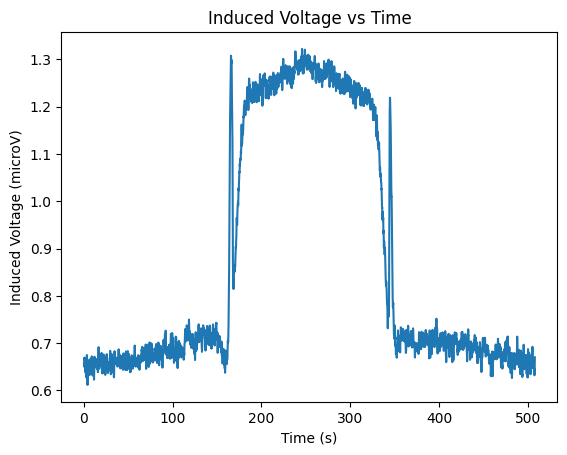

In [165]:
# Reconstruct kGauss vs Time and Induced Voltage vs Time graphs


# Separate columns in our dataframe

time = df["Time(s)"]
kGauss = df["Channel_1(V)"].abs() # Our field sweep is negative, but we only care about the amplitude, so we take the absolute value to make it more readible visually
voltage = df["Channel_2(V)"]
# angle = df["Channel_3(V)"]  --  Unused, here for clarity

# Plot kGauss vs Time Graph

plt.figure()  # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, kGauss)
plt.xlabel("Time (s)")
plt.ylabel("DC Field Strength (kG)")
plt.title("DC Field Strength vs Time")

# Plot Induced Voltage vs Time Graph

plt.figure() # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Induced Voltage (microV)")
plt.title("Induced Voltage vs Time")

plt.show()

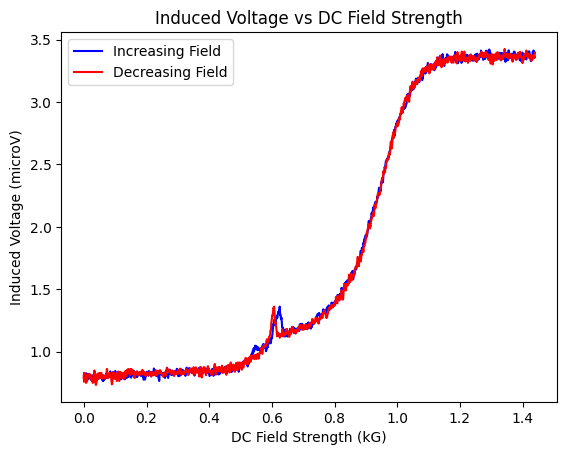

In [154]:
# Construct Induced Voltage vs kGauss graph


# Identify where our swept field reaches its maximum amplitude
max_field_idx = kGauss.idxmax() 

# Use max_field_idx to split our kGauss column into an upward field sweep and a downward field sweep - This is done to account for hysteresis in the measuring instruments and produce a more accurate critical field

# Split our data into two parts. One where our DC magnetic field is sweeping upward another where it is sweeping downward

up_sweep = df.iloc[:max_field_idx + 1] # .iloc keeps the rows in our .txt file from the 0 index to the max_field_idx index
down_sweep = df.iloc[max_field_idx:] # .iloc keeps the rows in our .txt file from the max_field_idx index to our last index

# These both contain the row at the max_field_idx for an overlap of 1

# Separate kGauss data for our upward sweep and our downward sweep 
kGauss_up = up_sweep["Channel_1(V)"].abs()
kGauss_down = down_sweep["Channel_1(V)"].abs()

# Separate voltage data for our upward sweep and our downward sweep
voltage_up = up_sweep["Channel_2(V)"]
voltage_down = down_sweep["Channel_2(V)"]

# Graph Induced Voltage vs kGauss


plt.figure  # Could replace this with plt.subplot(), depending on vibes
plt.plot(kGauss_up, voltage_up, label='Increasing Field', color='blue',) # Upward sweep is blue
plt.plot(kGauss_down, voltage_down, label='Decreasing Field', color='red') # Downward sweep is red
plt.xlabel("DC Field Strength (kG)")
plt.ylabel("Induced Voltage (microV)")
plt.title("Induced Voltage vs DC Field Strength")

plt.legend()
plt.show()

In [23]:
# Find the critical DC field

# We define the critical field as the field at the peak of the induced voltage spike. We use the average of the critical field from both the upward sweep and the downward sweep, to help combat hysteresis effects


# Find the index of the peak of the induced voltage spike
volt_up_max_idx = voltage_up.idxmax()
volt_down_max_idx = voltage_down.idxmax()

# Find the critical field for each sweep
crit_field_up = kGauss_up.loc[volt_up_max_idx]
crit_field_down = kGauss_down.loc[volt_down_max_idx]

# Average the two
crit_field = (crit_field_up + crit_field_down) / 2

# Print critical field
print(f"The critical field is {crit_field} kGauss")

The critical field is 0.512224003061809 kGauss


Outlier at index 226 corrected using bridge.
Outlier at index 228 corrected using bridge.
Outlier at index 297 corrected using bridge.
Outlier at index 298 corrected using bridge.
Outlier at index 549 corrected using bridge.
Outlier at index 634 corrected using bridge.
Outlier at index 737 corrected using bridge.
Outlier at index 738 corrected using bridge.
Outlier at index 739 corrected using bridge.
Outlier at index 740 corrected using bridge.
Outlier at index 741 corrected using bridge.
Outlier at index 742 corrected using bridge.
Outlier at index 743 corrected using bridge.
Outlier at index 744 corrected using bridge.
Outlier at index 745 corrected using bridge.
Outlier at index 746 corrected using bridge.
Outlier at index 747 corrected using bridge.
Outlier at index 748 corrected using bridge.
Outlier at index 749 corrected using bridge.
Outlier at index 750 corrected using bridge.
Outlier at index 751 corrected using bridge.
Outlier at index 831 corrected using bridge.
Outlier at

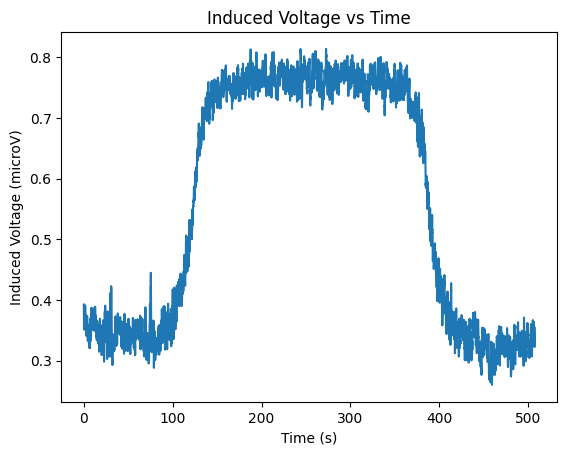

In [76]:

def bridge_outliers(data, window_size=30, n_sigma=3):
    cleaned_data = np.copy(data)
    n = len(data)
    
    for i in range(window_size, n - 1):
        # 1. Establish the "Healthy" Baseline using Median/MAD
        # This ensures the 15-point spike doesn't inflate our limits
        window = data[i - window_size : i]
        median = np.median(window)
        mad = np.median(np.abs(window - median))
        sigma_robust = mad * 1.4826 
        
        upper_bound = median + (n_sigma * sigma_robust)
        lower_bound = median - (n_sigma * sigma_robust)
        
        # 2. Check if current point is outside acceptable range
        if data[i] > upper_bound or data[i] < lower_bound:
            
            # Find first VALID point to the LEFT
            left_val = median  # Default fallback
            for l in range(i - 1, -1, -1):
                if lower_bound <= data[l] <= upper_bound:
                    left_val = data[l]
                    break
            
            # Find first VALID point to the RIGHT
            right_val = median # Default fallback
            for r in range(i + 1, n):
                if lower_bound <= data[r] <= upper_bound:
                    right_val = data[r]
                    break
            
            # 3. Replace with the average of the found "healthy" neighbors
            cleaned_data[i] = (left_val + right_val) / 2
            print(f"Outlier at index {i} corrected using bridge.")
            
    return cleaned_data


clean_signal = bridge_outliers(voltage, window_size=40, n_sigma=3)


plt.figure() # Could replace this with plt.subplot(), depending on vibes
plt.plot(time, clean_signal)
plt.xlabel("Time (s)")
plt.ylabel("Induced Voltage (microV)")
plt.title("Induced Voltage vs Time")

plt.show()